In [ ]:
%load_ext autoreload
%autoreload 2

from spatial_tcr.utils import switch_cwd_to_root

switch_cwd_to_root()

import spatialtools as st

figure_dir = "figures/revision/figure-2"
st.utils.setup_plotting(figure_dir)

import os

import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import scanpy as sc

from spatial_tcr.tcr import get_tcr_genes

In [2]:
data_dir = "data/xenium/processed"
path = f"{data_dir}/06.2-kidney_tcr_filtered.h5ad"
adata = sc.read_h5ad(path)
adata.obs["cell_id"] = adata.obs.index.str.split("output").str[0]
adata = adata[adata.obs["condition"] == "ANCA"].copy()
adata

AnnData object with n_obs × n_vars = 389390 × 431
    obs: 'sample', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'slide', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'n_counts', 'condition', 'cc', 'cell_type_no_tcr', 'cell_type_no_tcr_prob', 'tcell_subtype', 'cell_type_l1', 'cell_type_l2', 'is_ATL', 'is_B', 'is_CNT', 'is_DCT', 'is_DTL', 'is_EC', 'is_FIB', 'is_IC', 'is_MAST', 'is_MC', 'is_MDC', 'is_Mac', 'is_N', 'is_NEU', 'is_PC', 'is_PEC', 'is_PL', 'is_POD', 'is_PT', 'is_PapE', 'is_T', 'is_TAL', 'is_VSM/P', 'is_cDC', 'is_cycMNP', 'is_glom. EC', 'is_pDC', 'is_unknown', 'leiden', 'glom_annot', 'in_glom', 'tcell_density_group', 'tcell_density', 'tcell_infiltrate', 'cell_id'
    var: 'n_

## Find potential examples

In [3]:
av_genes, bv_genes, dv_genes, gv_genes, tv_genes = get_tcr_genes(adata)

Found 35 TRAV genes, 31 TRBV genes, 3 TRDV genes, 14 TRGV genes


In [4]:
example_cell_ids = [["iofookae-1", "iogbbaeo-1"]]

In [5]:
for ci in example_cell_ids:
    ad_tmp = adata[adata.obs["cell_id"].isin(ci), tv_genes].copy()
    var_names = np.array(ad_tmp.var_names)
    X = ad_tmp.layers["counts"].toarray().astype(bool)
    genes = [v for row in X for v in var_names[row]]
    print(genes)

['TRDV2', 'TRGV1', 'TRGV9', 'TRAV13-2', 'TRBV12']


In [6]:
base_dir = "/bonn-epyc/projects/spatialTCR/20240719__094819__human_kidney_7_TCR"

samples = adata.obs["sample"].unique()
sample_to_data_dir = dict(
    zip(samples, [os.path.join(base_dir, f"output-{sample}") for sample in samples])
)
cc_to_sample = adata.obs[["cc", "sample"]].apply(np.array).drop_duplicates().values
cc_to_sample = dict(zip(cc_to_sample[:, 0], cc_to_sample[:, 1]))

cc_to_data_dir = {cc: sample_to_data_dir[sample] for cc, sample in cc_to_sample.items()}

In [7]:
index = 0

In [8]:
xlength = 21
# ylength = int(xlength * (2 / 3))
ylength = xlength

In [9]:
adata.obs["cell_color"] = adata.obs["cell_type_l2"].astype(str)
adata.obs.loc[~(adata.obs["cell_type_l1"] == "T"), "cell_color"] = "other"
adata.obs.loc[adata.obs["cell_id"].isin(example_cell_ids[index]), "cell_color"] = (
    "highlight_"
    + adata.obs.loc[adata.obs["cell_id"].isin(example_cell_ids[index]), "cell_color"]
)
adata.obs["cell_color"].value_counts()

# adata.obs["cell_color"] = adata.obs["cell_id"]

cell_color
other             369769
CD4+                9124
CD8+                6430
NKT-like            1684
Tregs               1135
MAIT                 807
gdT                  439
highlight_gdT          1
highlight_CD4+         1
Name: count, dtype: int64

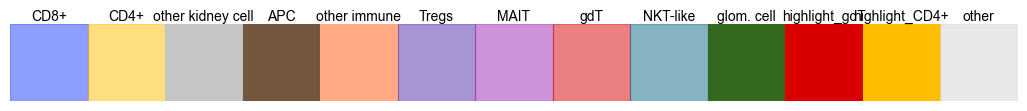

In [10]:
from spatial_tcr.colors import colors_sub

palette = colors_sub.copy()
palette["highlight_gdT"] = palette["gdT"]
palette["highlight_CD4+"] = palette["CD4+"]
palette_alpha = {
    ct: mcolors.to_rgba(palette[ct], alpha=0.0 if ct == "NA" else 1)
    for ct in palette.keys()
}
for k in adata.obs["cell_color"].unique():
    if k not in palette_alpha:
        palette_alpha[k] = mcolors.to_rgba("lightgray", alpha=0.5)
    if "highlight" not in k:
        palette_alpha[k] = mcolors.to_rgba(palette_alpha[k], alpha=0.5)

st.pl.utils.plot_palette_dict(palette_alpha)

In [11]:
[g for g in adata.var_names if "CD3" in g]

['CD3D', 'CD3E', 'CD3G']

{'TRDV2': ['TRDV2'], 'TRGV1': ['TRGV1'], 'TRGV9': ['TRGV9'], 'TRAV13-2': ['TRAV13-2'], 'TRBV12': ['TRBV12-3', 'TRBV12-4', 'TRBV12-5']}
Loading images from ['/bonn-epyc/projects/spatialTCR/20240719__094819__human_kidney_7_TCR/output-XETG00088__0029041__Region_5__20240719__095642/morphology_focus/morphology_focus_0000.ome.tif', '/bonn-epyc/projects/spatialTCR/20240719__094819__human_kidney_7_TCR/output-XETG00088__0029041__Region_5__20240719__095642/morphology_focus/morphology_focus_0001.ome.tif', '/bonn-epyc/projects/spatialTCR/20240719__094819__human_kidney_7_TCR/output-XETG00088__0029041__Region_5__20240719__095642/morphology_focus/morphology_focus_0002.ome.tif', '/bonn-epyc/projects/spatialTCR/20240719__094819__human_kidney_7_TCR/output-XETG00088__0029041__Region_5__20240719__095642/morphology_focus/morphology_focus_0003.ome.tif']


  0%|          | 0/4 [00:00<?, ?it/s]

The image has shape: (27304, 20012, 4) with channel names: ['DAPI', 'CD45', 'RNA', 'Vimentin']
cell_ids_sub: ['aaaahmnk-1', 'aaaaiggn-1', 'aaaclfjm-1', 'aaafgfpd-1', 'aaannfpo-1', 'aaaoandg-1', 'aabbeljk-1', 'aabcfdkg-1', 'aabcigjj-1', 'aabdhcbi-1', 'aabfcdgk-1', 'aabfgeha-1', 'aabhfeac-1', 'aabhjbdf-1', 'aabhkkol-1', 'aabhpmnk-1', 'aabkkgbi-1', 'aabkobof-1', 'aachinjc-1', 'aacjckoc-1', 'aackbhmd-1', 'aackmleh-1', 'aadcngpb-1', 'aaddidhc-1', 'aadhelji-1', 'aadhkiad-1', 'aadifjag-1', 'aadiiaca-1', 'aadiongf-1', 'aadkomfc-1', 'aadljbpe-1', 'aadmjinj-1', 'aadnabka-1', 'aadpciem-1', 'aadpgdfl-1', 'aaebanck-1', 'aaeblfcm-1', 'aaebnoae-1', 'aaecolhg-1', 'aaepdpdb-1', 'aafapion-1', 'aafbdlla-1', 'aafbgcdj-1', 'aafcnjfk-1', 'aafdlblc-1', 'aafeejdg-1', 'aaffmmen-1', 'aafikkaf-1', 'aafpcgnj-1', 'aagddmic-1', 'aagfdafi-1', 'aagfjfmm-1', 'aaglcopo-1', 'aaglnehc-1', 'aahbphmf-1', 'aahcmigb-1', 'aahdeboe-1', 'aahdjhhi-1', 'aahdlpkm-1', 'aahelooi-1', 'aaheonjh-1', 'aahfehjf-1', 'aahfenha-1', 'aahiiac

  0%|          | 0/4 [00:00<?, ?it/s]

The image has shape: (27304, 20012, 4) with channel names: ['DAPI', 'CD45', 'RNA', 'Vimentin']
cell_ids_sub: ['iofookae-1', 'iofplkcn-1', 'iogbbaeo-1']
sub_nuc_boundaries.shape: (75, 4)
sub_cell_boundaries.shape: (75, 4)
xlim: [1819.     1840.0375], ylim: [3815.8625 3836.9   ]
sub_img.shape: (99, 99, 4)
sub_transcripts.shape: (264, 13)


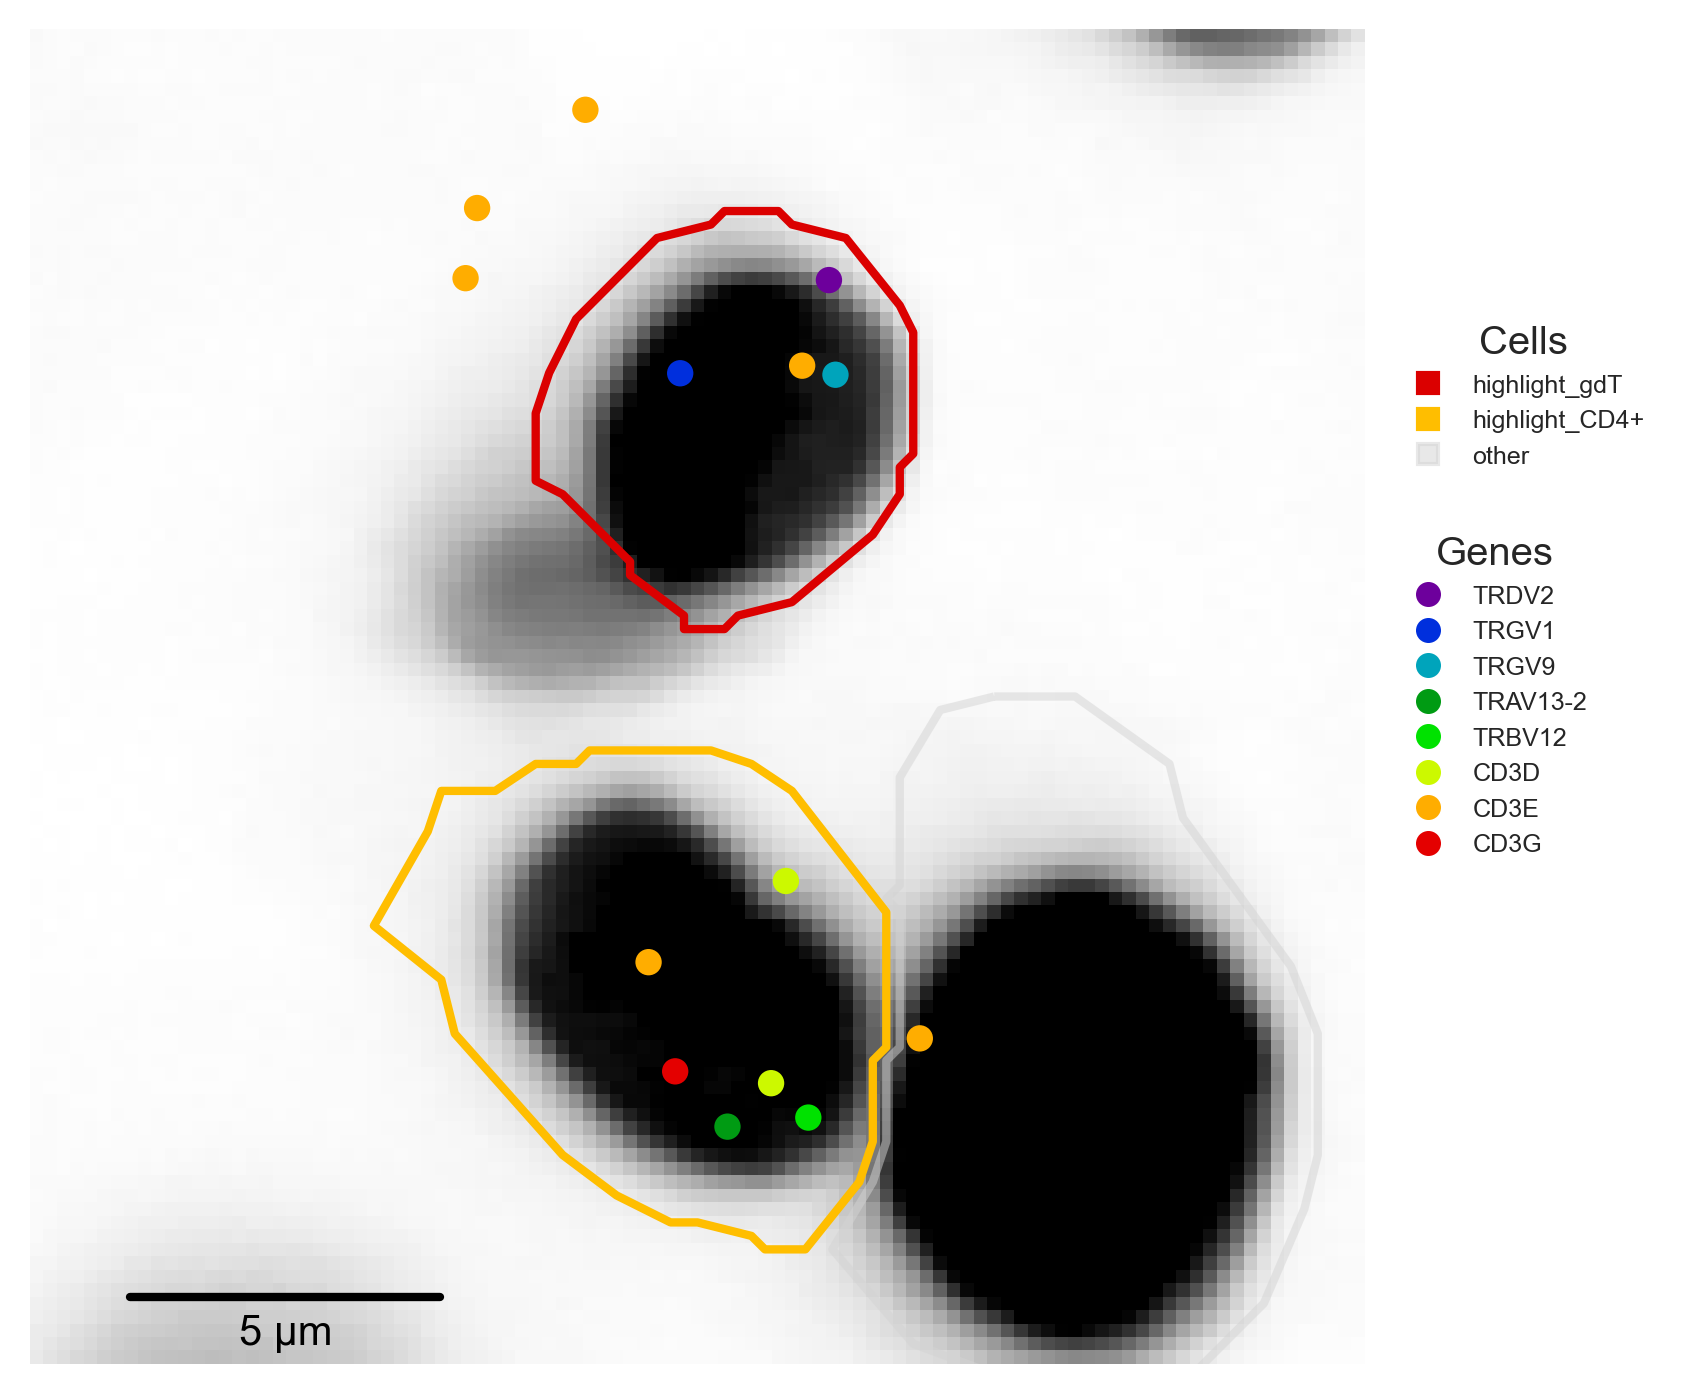

In [12]:
for cell_ids in example_cell_ids[index : index + 1]:
    # get the av bv dv gv genes expressed in the cells
    ad_tmp = adata[adata.obs["cell_id"].isin(cell_ids), tv_genes].copy()
    var_names = np.array(ad_tmp.var_names)
    X = ad_tmp.layers["counts"].toarray().astype(bool)
    genes = [v for row in X for v in var_names[row]]
    genes = {g: [g] for g in genes}
    if "TRBV6" in genes:
        genes["TRBV6"] = ["TRBV6-1", "TRBV6-2", "TRBV6-5", "TRBV6-7"]
    if "TRBV10" in genes:
        genes["TRBV10"] = ["TRBV10-1", "TRBV10-2", "TRBV10-3"]
    if "TRBV12" in genes:
        genes["TRBV12"] = ["TRBV12-3", "TRBV12-4", "TRBV12-5"]
    if "TRAV12" in genes:
        genes["TRAV12"] = ["TRAV12-1", "TRAV12-2", "TRAV12-3"]
    if "TRBV4" in genes:
        genes["TRBV4"] = ["TRBV4-1", "TRBV4-2"]
    if "TRAV19_21" in genes:
        genes["TRAV19_21"] = ["TRAV19", "TRAV21"]
    print(genes)
    genes["CD3D"] = ["CD3D"]
    genes["CD3E"] = ["CD3E"]
    genes["CD3G"] = ["CD3G"]

    sample = adata[adata.obs["cell_id"].isin(cell_ids)].obs["cc"].iloc[0]
    data_dir = cc_to_data_dir[sample]
    ad_zoom, fig, ax, legends = st.pl.spatial.plot_cells_view(
        adata,
        data_dir=data_dir,
        sample=sample,
        cell_ids=cell_ids,
        color_key="cell_color",
        palette=palette_alpha,
        # palette=None,
        xlength=xlength,
        ylength=ylength,
        genes=genes,
        tick_size=5,
        gene_kwargs={"s": 40},
        img_kwargs={"vmax": 4000},
    )
    plt.savefig(
        os.path.join(figure_dir, "gdT_abT_example.pdf"),
        bbox_inches="tight",
        dpi=300,
        transparent=True,
        pad_inches=0,
    )